In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Imports and configuration**

In [2]:
import os
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, ConfusionMatrixDisplay
)
from torchvision.transforms import (
    CenterCrop, RandomResizedCrop,
    ColorJitter, Compose, Normalize,
    RandomHorizontalFlip, Resize, ToTensor
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (
    AutoImageProcessor, AutoModelForImageClassification,
    get_cosine_schedule_with_warmup
)

In [ ]:
MODEL_ID = "microsoft/swin-tiny-patch4-window7-224"
OUTPUT_DIR = "/content/drive/MyDrive/Fine tuned models/swin_beans_best"
IMAGE_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
print("Device: ", device)

Device:  cuda


**Dataset and pretrained model load**

In [4]:
dataset = load_dataset("AI-Lab-Makerere/beans")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  144MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.5MB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


In [5]:
label_names = dataset["train"].features["labels"].names

id2label = {
    class_id: label for class_id, label in enumerate(label_names)
}

label2id = {
    label: class_id for class_id, label in enumerate(label_names)
}

print("Classes: ", label_names)

Classes:  ['angular_leaf_spot', 'bean_rust', 'healthy']


In [6]:
image_processor = AutoImageProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageClassification.from_pretrained(
    MODEL_ID
).to(device)

model.eval()

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (attention): SwinAttention(
                (q_proj): Linear(in_features=96, out_features=96, bias=True)
                (k_proj): Linear(in_features=96, out_features=96, bias=True)
                (v_proj): Linear(in_features=96, out_features=96, bias=True)
                (o_proj): Linear(in_features=96, out_features=96, bias=True)
                (relative_position_bias): SwinRelativePositionBias()
              )
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
         

**Pretrained inference using real bean image** 

In [7]:
sample =dataset["validation"][0]
image = sample["image"].convert("RGB")
true_label = id2label[sample["labels"]]

inputs = image_processor(
    images=image,
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

with torch.inference_mode():
    outputs = model(
        pixel_values=pixel_values
    )
probabilities = torch.softmax(outputs.logits, dim=-1)[0]

top_scores, top_indices = torch.topk(
    probabilities, k=3
)

Original image size: (500, 500)
Model input shape   : torch.Size([1, 3, 224, 224])
Logits shape        : torch.Size([1, 1000])
Bean ground truth   : angular_leaf_spot


Pretrained ImageNet predictions:
ant, emmet, pismire 0.15
leaf beetle, chrysomelid 0.15
pot, flowerpot 0.06


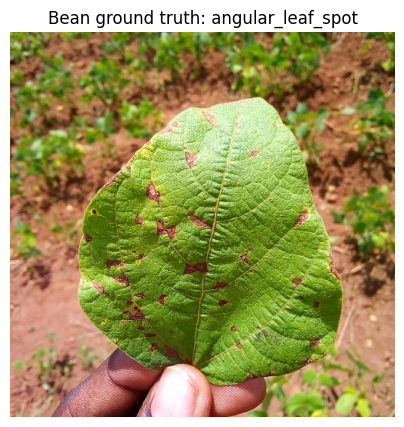

In [8]:
print("Original image size:", image.size)
print("Model input shape   :", pixel_values.shape)
print("Logits shape        :", outputs.logits.shape)
print("Bean ground truth   :", true_label)
print("\n\nPretrained ImageNet predictions:")

for class_id, score in zip(
    top_indices.tolist(), top_scores.tolist()
):
    print(
        f"{model.config.id2label[class_id]}"
        f" {score:.2f}"
    )

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f"Bean ground truth: {true_label}")
plt.axis("off")
plt.show()

**Training and evaluation transforms**

In [9]:
normalize = Normalize(
    mean=image_processor.image_mean,
    std=image_processor.image_std
)

train_transform = Compose([
    RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    RandomHorizontalFlip(p=0.5),
    ColorJitter(
        brightness=0.15, contrast=0.15, saturation=0.10
    ),
    ToTensor(),
    normalize,
])

evaluation_transform = Compose([
    Resize(256),
    CenterCrop(IMAGE_SIZE),
    ToTensor(),
    normalize
])

def apply_train_transform(examples):
    examples["pixel_values"] = [
        train_transform(image.convert("RGB"))
        for image in examples["image"]
    ]
    return examples

def apply_evaluation_transform(examples):
    examples["pixel_values"] = [
        evaluation_transform(image.convert("RGB"))
        for image in examples["image"]
    ]
    return examples

In [10]:
train_dataset = dataset["train"].with_transform(apply_train_transform)

test_dataset = dataset["test"].with_transform(
    apply_evaluation_transform
)

evaluation_dataset = dataset["validation"].with_transform(
    apply_evaluation_transform
)

**DataLoaders**

In [11]:
BATCH_SIZE = 16
def collate_fn(batch):
    pixel_values = torch.stack([
        item["pixel_values"] for item in batch
    ])
    labels = torch.tensor([
        item["labels"] for item in batch
    ], dtype=torch.long)
    
    return {
        "pixel_values": pixel_values,
        "labels": labels,
    }

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

validation_loader = DataLoader(
    dataset=evaluation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

batch = next(iter(train_loader))
print("Images: ", batch["pixel_values"].shape)
print("Labels: ", batch["labels"].shape)
print("First labels:", batch["labels"][:10])

Images:  torch.Size([16, 3, 224, 224])
Labels:  torch.Size([16])
First labels: tensor([1, 1, 0, 1, 0, 2, 1, 0, 1, 1])


### Swin Fine-tuning Setup

**New three-class Swin model**

In [12]:
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


fine_tune_model = AutoModelForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

print("Classifier: ", fine_tune_model.classifier)
print("Target classes: ", fine_tune_model.config.id2label)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Classifier:  Linear(in_features=768, out_features=3, bias=True)
Target classes:  {0: 'angular_leaf_spot', 1: 'bean_rust', 2: 'healthy'}


**Partial fine-tuning**

In [ ]:
for parameter in fine_tune_model.parameters():
    parameter.require_grad = False

final_block = fine_tune_model.swin.encoder.layers[-1].blocks[-1]
final_layer_norm = fine_tune_model.swin.layernorm
classifier = fine_tune_model.classifier

for module in [final_block, final_layer_norm, classifier]:
    for parameter in module.parameters():
        parameter.require_grad = True
    
total_parameters = sum(
    parameter.numel() 
    for parameter in fine_tune_model.parameters()
)

number_trainable_parameters = sum(
    parameter.numel() 
    for parameter in fine_tune_model.parameters() 
    if parameter.require_grad
)

trainable_percentage = 100 * number_trainable_parameters / total_parameters

In [14]:
print(f"Total parameters    : {total_parameters:,}")
print("Trainable parameters: ", number_trainable_parameters)
print("Trainable percentage: ", trainable_percentage)

Total parameters    : 27,521,661
Trainable parameters:  7095771
Trainable percentage:  25.782495467842583


**Evaluation function**

In [15]:
def evaluate_model(model, data_loader):
    model.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_labels = []
    
    with torch.inference_mode():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            
            total_loss += outputs.loss.item()
            prediction = outputs.logits.argmax(dim=-1)
            
            all_predictions.extend(prediction.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    
    average_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)
    
    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "predictions": all_predictions,
        "labels": all_labels,
    }

In [17]:
before_training = evaluate_model(
    fine_tune_model,
    validation_loader,
)

print("BEFORE FINE-TUNING")
print("=" * 40)
print("Validation loss    : ",f"{before_training['loss']:.4f}")
print("Validation accuracy: ", f"{before_training['accuracy']:.4f}")
print("Validation macro F1: ", f"{before_training['macro_f1']:.4f}")

BEFORE FINE-TUNING
Validation loss    :  1.0856
Validation accuracy:  0.4286
Validation macro F1:  0.3485


**Optimizer and scheduler**

In [18]:
EPOCHS = 5
backbone_parameters = list(final_block.parameters()) + list(final_layer_norm.parameters())

classifier_parameters = list(classifier.parameters())

optimizer = torch.optim.AdamW([
    {
        "params" : backbone_parameters,
        "lr" : 2e-5
    },
    {
        "params" : classifier_parameters,
        "lr" : 5e-4
    },
], weight_decay=0.01)

total_training_steps = len(train_loader) * EPOCHS
warmup_steps = 0.1 * total_training_steps
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

parameter_to_update = [
    parameter
    for parameter in fine_tune_model.parameters()
    if parameter.require_grad
]

print("Epochs        :", EPOCHS)
print("Training steps:", total_training_steps)
print("Warmup steps  :", warmup_steps)
print("AMP enabled   :", use_amp)

Epochs        : 5
Training steps: 325
Warmup steps  : 32.5
AMP enabled   : True


**Training loop**

In [19]:
history = {
    "train_loss": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "validation_f1": [],
}

best_validation_f1 = -1.0
best_validation_accuracy = -1.0

for epoch in range(1, EPOCHS + 1):
    fine_tune_model.train()
    
    running_loss = 0.0
    progress_bar = tqdm(
        train_loader, desc=f"Epoch {epoch}/{EPOCHS}",
    )
    
    for batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad(set_to_none=True)
        
        with torch.autocast(
            device_type=device.type, enabled=use_amp
        ):
            outputs = fine_tune_model(
                pixel_values=pixel_values,
                labels=labels,
            )
            loss = outputs.loss
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            parameter_to_update, max_norm=1.0
        )
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        running_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")
    
    average_train_loss = running_loss / len(train_loader)
    validation_result = evaluate_model(fine_tune_model, validation_loader)
    
    history["train_loss"].append(average_train_loss)
    history["validation_loss"].append(validation_result["loss"])
    history["validation_accuracy"].append(validation_result["accuracy"])
    history["validation_f1"].append(validation_result["macro_f1"])
    
    print(
        f"\nEpoch {epoch}/{EPOCHS} | "
        f"Train loss: {average_train_loss:.4f} | "
        f"Val loss: "
        f"{validation_result['loss']:.4f} | "
        f"Val accuracy: "
        f"{validation_result['accuracy']:.4f} | "
        f"Val macro F1: "
        f"{validation_result['macro_f1']:.4f}"
    )
    
    if (
        validation_result["macro_f1"]
        > best_validation_f1
    ):
        best_validation_f1 =validation_result["macro_f1"]
        best_validation_accuracy = validation_result["accuracy"]
        fine_tune_model.save_pretrained(OUTPUT_DIR)
        image_processor.save_pretrained(OUTPUT_DIR)
        print("Best checkpoint saved")

Epoch 1/5:   0%|          | 0/65 [00:00<?, ?it/s]


Epoch 1/5 | Train loss: 0.7675 | Val loss: 0.3234 | Val accuracy: 0.8797 | Val macro F1: 0.8801


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint saved


Epoch 2/5:   0%|          | 0/65 [00:00<?, ?it/s]

...


Epoch 4/5 | Train loss: 0.1698 | Val loss: 0.1044 | Val accuracy: 0.9549 | Val macro F1: 0.9550


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint saved


Epoch 5/5:   0%|          | 0/65 [00:00<?, ?it/s]


Epoch 5/5 | Train loss: 0.1601 | Val loss: 0.1057 | Val accuracy: 0.9549 | Val macro F1: 0.9550


**Learning curves**

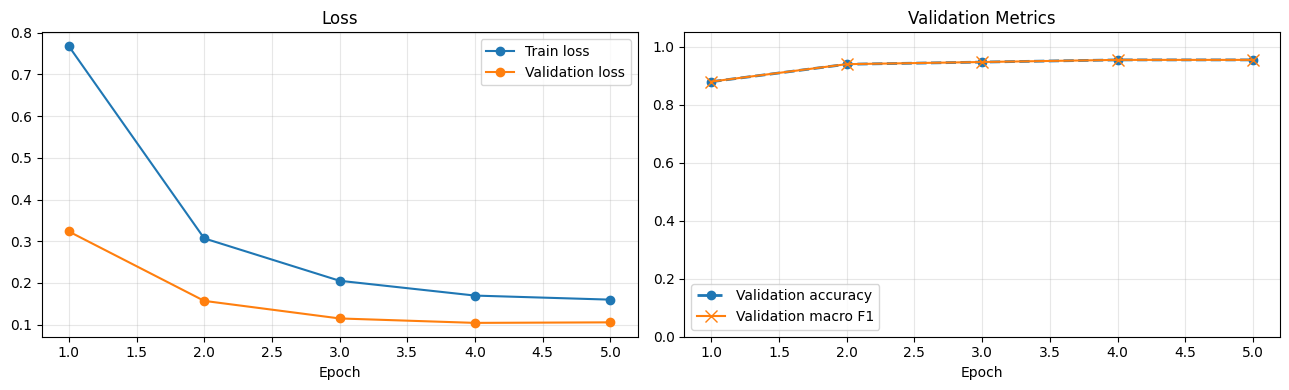

In [22]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], marker='o', label="Train loss")
axes[0].plot(epochs, history["validation_loss"], marker='o', label="Validation loss")

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["validation_accuracy"], marker="o", linestyle="--", linewidth=2, label="Validation accuracy")
axes[1].plot(epochs, history["validation_f1"], marker="x", markersize=8, label="Validation macro F1")

axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Best model test evaluation**

In [23]:
best_model = AutoModelForImageClassification.from_pretrained(
    OUTPUT_DIR
).to(device)

best_model.eval()

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (attention): SwinAttention(
                (q_proj): Linear(in_features=96, out_features=96, bias=True)
                (k_proj): Linear(in_features=96, out_features=96, bias=True)
                (v_proj): Linear(in_features=96, out_features=96, bias=True)
                (o_proj): Linear(in_features=96, out_features=96, bias=True)
                (relative_position_bias): SwinRelativePositionBias()
              )
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
         

In [24]:
test_result = evaluate_model(best_model, test_loader)
print("FINAL TEST RESULT")
print("=" * 45)

print("Test loss     : ", f"{test_result['loss']:.4f}")
print("Test accuracy : ", f"{test_result['accuracy']:.4f}")
print("Test macro F1 : ", f"{test_result['macro_f1']:.4f}")

print("\nClassification report:\n")
print(classification_report(
    test_result["labels"], test_result["predictions"],
    labels=list(range(len(label_names))),
    target_names=label_names
))

FINAL TEST RESULT
Test loss     :  0.2236
Test accuracy :  0.9219
Test macro F1 :  0.9220

Classification report:

                   precision    recall  f1-score   support

angular_leaf_spot       0.93      0.95      0.94        43
        bean_rust       0.88      0.88      0.88        43
          healthy       0.95      0.93      0.94        42

         accuracy                           0.92       128
        macro avg       0.92      0.92      0.92       128
     weighted avg       0.92      0.92      0.92       128



**Confusion matrix**

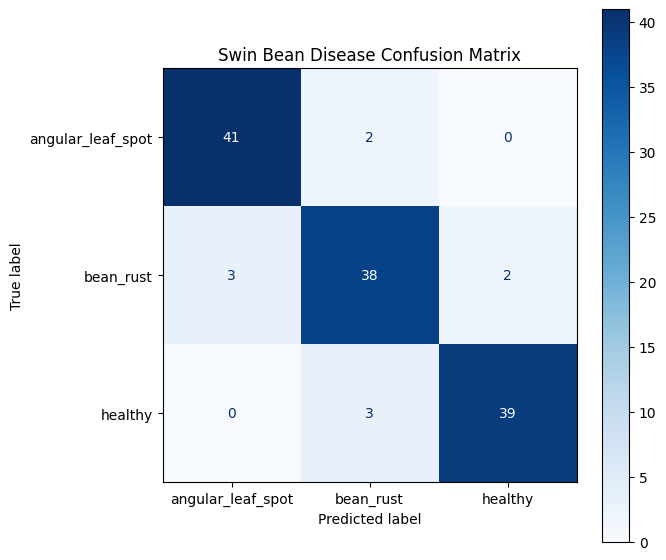

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    test_result["labels"],
    test_result["predictions"],
    labels=list(range(len(label_names))),
    display_labels=label_names,
    cmap="Blues",
    ax=ax,
)

plt.title("Swin Bean Disease Confusion Matrix")
plt.tight_layout()
plt.show()

**Prediction function**

In [26]:
def predict_bean_image(image, model=best_model, top_k=3):
    inputs = image_processor(
        images=image.convert("RGB"),
        return_tensors="pt",
    )
    pixel_values = inputs["pixel_values"].to(device)

    with torch.inference_mode():
        logits = model(pixel_values=pixel_values).logits

    probabilities = torch.softmax(logits, dim=-1)[0]
    top_k = min(top_k, model.config.num_labels)
    
    scores, indices = torch.topk(probabilities,k=top_k)
    predictions = []

    for class_id, score in zip(
        indices.tolist(),
        scores.tolist(),
    ):
        predictions.append({
            "label": (model.config.id2label[class_id]),
            "confidence": score
        })

    return predictions

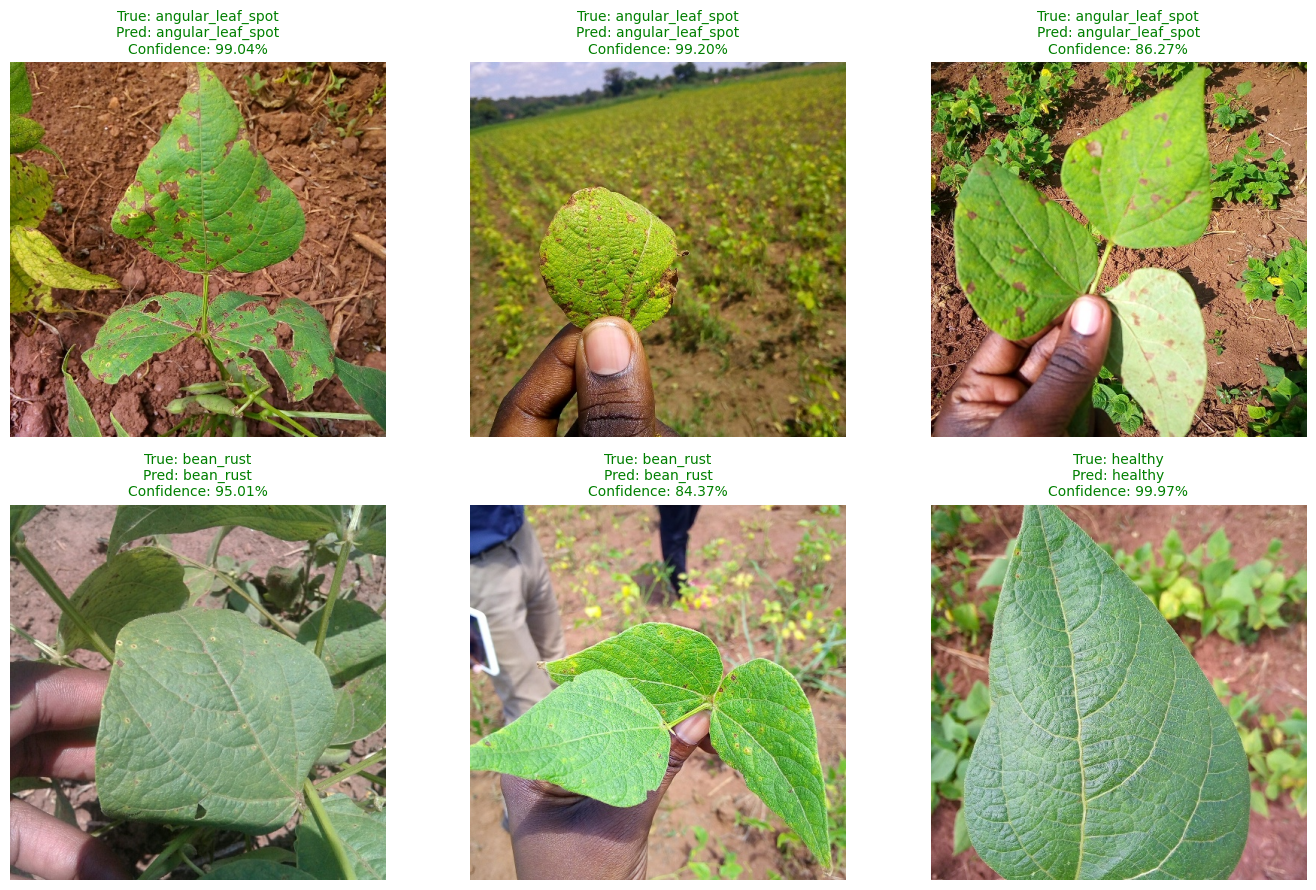

In [27]:
sample_indices = [0, 20, 40, 60, 80, 100]
fig, axes = plt.subplots(2, 3, figsize=(14, 9),)

for axis, sample_index in zip(
    axes.flat,
    sample_indices,
):
    sample = dataset["test"][sample_index]
    image = sample["image"].convert("RGB")

    true_label = id2label[sample["labels"]]
    predictions = predict_bean_image(image, top_k=3,)

    predicted_label = predictions[0]["label"]
    confidence = predictions[0]["confidence"]

    title_color = (
        "green"
        if predicted_label == true_label
        else "red"
    )

    axis.imshow(image)
    axis.set_title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Confidence: {confidence:.2%}",
        color=title_color,
        fontsize=10,
    )
    axis.axis("off")

plt.tight_layout()
plt.show()